In [1]:
import random 
import math
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#Valores de las variables
Nind = 5
Lind = 20
Pc = 0.7
Pm = 1/15
Maxgen = 100
Nvar = 1
rango = np.array([[0, 0.875], [0,0]])

In [3]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

def decodifica(genotipo, rango):
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)

    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i,j] = np.sum(potencias * genotipo[i, (j*Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2**Lvar - 1) * fenotipo[:, i])
    return fenotipo

def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        x = fenotipo[i, 0]
        t = (11 / 2) * (x - 7 / 2)
        objv[i, 0] = (1 - t**2) * np.cos(t) + 1 + 2

    return objv


def rankeo(objv, direccion):
    SP = 2
    Nind, Nobj = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else: 
        nuevo_objv = np.sort(-1 * objv, axis=0)
    
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0)

    aptitud[posori, 0] = apt.reshape(-1, 1)

    return aptitud

def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]
    
    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen

def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind))
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza < Pc:
            corte = np.random.randint(1, Lind - 1)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]
    
    nuevo_gen = aux_gen

    return nuevo_gen

def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    muta = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, muta)
    
    return nuevo_gen

In [4]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)

generaciones = 1000

Mejor = np.full((Maxgen, 1), np.nan) #Referencia para almacenar el mejor valor de cada generación
Mejor_cromosoma = np.zeros((Maxgen, Lind)) #Referencia para almacenar el mejor cromosoma de cada generación
objv = objfun(fenotipo) #Evaluacion de la función objetivo para cada individuo

while generaciones < Maxgen:
    aptitud = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)
    genotipo = nuevo_gen
    objv = nuevo_objv
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

# Gráfica

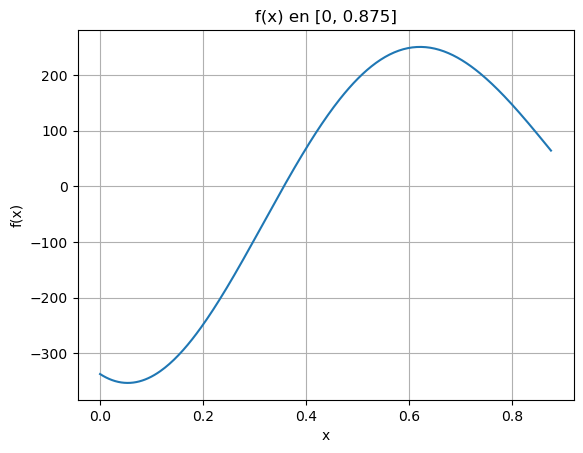

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    t = (11 / 2) * (x - 7 / 2)
    return (1 - t**2) * np.cos(t) + 1 + 2


x = np.linspace(0, 0.875, 300)
y = f(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) en [0, 0.875]")
plt.grid(True)
plt.show()